# Quantum Key Distribution: BB84
Implementation and run of the BB84 protocol.

In [ ]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, circuit
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram, plot_bloch_multivector
from numpy.random import randint

print("Imports Successful")

Imports Successful


Now lets set up the circuit and run it:

In [ ]:
##########################################
# for Eve to enter make the flagEve True
# flagEve = False
flagEve = True

In [ ]:
if (flagEve):
    calice, cbob, ceve = ClassicalRegister(2, name="calice"), ClassicalRegister(2, name="cbob"), ClassicalRegister(2, name="ceve")
    qr = QuantumRegister(4, name="q")
    qc = QuantumCircuit(qr, calice, cbob, ceve)
else:
    calice, cbob = ClassicalRegister(2, name="calice"), ClassicalRegister(2, name="cbob")
    qr = QuantumRegister(3, name="q")
    qc = QuantumCircuit(qr, calice, cbob)
# Alice prepares random key qubit
qc.h(0)
qc.measure(0,0)

# Alice uses another random qubit to select a random base
qc.barrier()
qc.h(1)
qc.measure(1,1)
qc.ch(1,0)
qc.barrier(label="Alice sents qubit")

# the key qubit is sent from Alice to Bob
############# Eve #############
if (flagEve):
    qc.h(3)

    qc.ch(3, 0)
    qc.measure(0, 4)

    qc.ch(3, 0)
    qc.measure(3, 5) #actually we dont need it
###############################
qc.barrier(label="Bob receives qubit")

# Bob selects a random base
qc.h(2)
qc.measure(2,3)
qc.ch(2,0)
qc.barrier()

# and measures the  qubit
qc.measure(0,2)

# Draw and simulate circuit
display(qc.draw())


┌───┐┌─┐ ░         ┌───┐ Alice sents qubit      ┌───┐┌─┐┌───┐   »
     q_0: ┤ H ├┤M├─░─────────┤ H ├─────────░──────────────┤ H ├┤M├┤ H ├───»
          └───┘└╥┘ ░ ┌───┐┌─┐└─┬─┘         ░              └─┬─┘└╥┘└─┬─┘   »
     q_1: ──────╫──░─┤ H ├┤M├──■───────────░────────────────┼───╫───┼─────»
                ║  ░ └───┘└╥┘              ░                │   ║   │     »
     q_2: ──────╫──░───────╫───────────────░────────────────┼───╫───┼─────»
                ║  ░       ║               ░         ┌───┐  │   ║   │  ┌─┐»
     q_3: ──────╫──░───────╫───────────────░─────────┤ H ├──■───╫───■──┤M├»
                ║  ░       ║               ░         └───┘      ║      └╥┘»
calice: 2/══════╩══════════╩════════════════════════════════════╬═══════╬═»
                0          1                                    ║       ║ »
  cbob: 2/══════════════════════════════════════════════════════╬═══════╬═»
                                                                ║       ║ »
  ceve: 2/══════════════════════════════════════════════════════╩═══════╩═»
                                                                0       1 »
«           Bob receives qubit         ┌───┐ ░ ┌─┐
«     q_0: ─────────░──────────────────┤ H ├─░─┤M├
«                   ░                  └─┬─┘ ░ └╥┘
«     q_1: ─────────░────────────────────┼───░──╫─
«                   ░          ┌───┐┌─┐  │   ░  ║ 
«     q_2: ─────────░──────────┤ H ├┤M├──■───░──╫─
«                   ░          └───┘└╥┘      ░  ║ 
«     q_3: ─────────░────────────────╫───────░──╫─
«                   ░                ║       ░  ║ 
«calice: 2/══════════════════════════╬══════════╬═
«                                    ║          ║ 
«  cbob: 2/══════════════════════════╩══════════╩═
«                                    1          0 
«  ceve: 2/═══════════════════════════════════════
«

36
out of 64


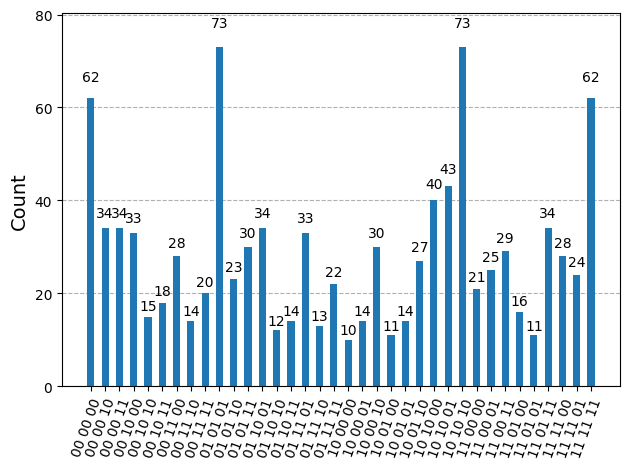

In [ ]:
aer_sim = Aer.get_backend('aer_simulator')
job = aer_sim.run(qc.decompose(reps=6), shots=1024, memory=True)
result = job.result()
hst = result.get_counts()
print(len(hst))
print("out of 64")
plot_histogram(hst)

Try to answer the following questions:

a) Why do some bars have a higher probability?

    Thoes are the bars where Alice and Bob basis bits are the same and key bits are also the same. If we call this condition hit, then 50% chance of hit is possible and 50% of miss. We have 4 states of hits and 8 of miss. To have probabiltly eqaul hit and miss, the hit bars should appear more then miss so bars are high.

b) What else is strange in this histogram? (Hint: count the bars!)

    There are 12 bars we should have 16 bars as we have 4 clasicle bits, so 2^4 = 16. Whenever basis are the same but the key bits no, it means there was a loose of information. So only 12 bars are shown.


In [ ]:
key = ""
icnt = 0
same_basis = 0
for cpairs in job.result().get_memory():
    # do alice and bob's setting match?
    # cpairs looks like "10 01" with the classical bits bob1, bob0, SPACE, alice1, alice0
    if (flagEve):
        eve, bob, alice = cpairs.split(" ")
    else:
        bob, alice = cpairs.split(" ")

    # test if bob and alice used the same base setting
    if bob[0]==alice[0]:
        # sanity check: are their secret key bits identical?
        same_basis += 1
        if bob[1]!=alice[1]:
            print("Error: key bits mismatch: "+cpairs)
            icnt = icnt+1
        else:
            # add bit to key
            key=key+bob[1]

print("found {0} matching bits ({1:3.1f}%)".format(len(key), 100.0*len(key)/len(job.result().get_memory())))
print("found {0} mismatches between Alice and Bobs keys".format(icnt))
print("secret key ({0} bits): {1}".format( str(len(key)), str(key)))
if same_basis > 0:
    qber = icnt / same_basis
else:
    qber = 0.0

threshold = 0.10  # 10% tolerable error, for noise
if qber > threshold:
    print("INTRUSION DETECTED: channel is not secure.")
else:
    print("No intrusion detected: channel appears clean.")

Error: key bits mismatch: 01 10 11
Error: key bits mismatch: 01 10 11
Error: key bits mismatch: 11 00 01
Error: key bits mismatch: 11 00 01
Error: key bits mismatch: 01 10 11
Error: key bits mismatch: 00 11 10
Error: key bits mismatch: 11 01 00
Error: key bits mismatch: 00 10 11
Error: key bits mismatch: 10 00 01
Error: key bits mismatch: 11 01 00
Error: key bits mismatch: 00 10 11
Error: key bits mismatch: 11 00 01
Error: key bits mismatch: 11 00 01
Error: key bits mismatch: 11 00 01
Error: key bits mismatch: 10 01 00
Error: key bits mismatch: 10 01 00
Error: key bits mismatch: 01 10 11
Error: key bits mismatch: 11 00 01
Error: key bits mismatch: 10 00 01
Error: key bits mismatch: 01 11 10
Error: key bits mismatch: 01 11 10
Error: key bits mismatch: 11 00 01
Error: key bits mismatch: 01 10 11
Error: key bits mismatch: 11 01 00
Error: key bits mismatch: 10 00 01
Error: key bits mismatch: 00 10 11
Error: key bits mismatch: 00 10 11
Error: key bits mismatch: 11 00 01
Error: key bits mism